In [1]:
import pandas as pd

In [2]:
train=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")
store=pd.read_csv("store.csv")

C:\Users\ramad\AppData\Local\Temp\ipykernel_24060\154166032.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train=pd.read_csv("train.csv")


In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Store shape:", store.shape)

Train shape: (1017209, 9)
Test shape: (41088, 8)
Store shape: (1115, 10)


In [4]:
display(train.head())
display(test.head())
display(store.head())

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
print("TRAIN")
train.info()

print("\nSTORE")
store.info()

TRAIN
<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 79.5+ MB

STORE
<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortm

In [6]:
print("Missing values in TRAIN:")
display(train.isnull().sum())

print("Missing values in STORE:")
display(store.isnull().sum())

Missing values in TRAIN:


Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

Missing values in STORE:


Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [7]:
df = train.merge(
    store,
    on="Store",
    how="left"
)

print("Shape:", df.shape)
display(df.head())

Shape: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)
print(df["Date"].min())
print(df["Date"].max())

datetime64[us]
2013-01-01 00:00:00
2015-07-31 00:00:00


In [9]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day
df["Quarter"] = df["Date"].dt.quarter
df["DayOfWeek"] = df["Date"].dt.dayofweek

In [10]:
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

In [11]:
print(df.shape)

display(
    df[
        [
            "Date",
            "Store",
            "Sales",
            "Customers",
            "Promo",
            "Year",
            "Month",
            "Week",
            "Quarter",
            "DayOfWeek",
            "IsWeekend"
        ]
    ].head(10)
)

(1017209, 24)


,Date,Store,Sales,Customers,Promo,Year,Month,Week,Quarter,DayOfWeek,IsWeekend
0,2015-07-31,1,5263,555,1,2015,7,31,3,4,0
1,2015-07-31,2,6064,625,1,2015,7,31,3,4,0
2,2015-07-31,3,8314,821,1,2015,7,31,3,4,0
3,2015-07-31,4,13995,1498,1,2015,7,31,3,4,0
4,2015-07-31,5,4822,559,1,2015,7,31,3,4,0
5,2015-07-31,6,5651,589,1,2015,7,31,3,4,0
6,2015-07-31,7,15344,1414,1,2015,7,31,3,4,0
7,2015-07-31,8,8492,833,1,2015,7,31,3,4,0
8,2015-07-31,9,8565,687,1,2015,7,31,3,4,0
9,2015-07-31,10,7185,681,1,2015,7,31,3,4,0


In [12]:
print("Open = 0:", (df["Open"] == 0).sum())
print("Open = 1:", (df["Open"] == 1).sum())

Open = 0: 172817
Open = 1: 844392


In [13]:
display(
    df.groupby("Open")["Sales"].agg(
        ["count", "mean", "sum"]
    )
)

,count,mean,sum
Open,,,
0,172817,0.000000,0
1,844392,6955.514291,5873180623


In [14]:
print(df.shape)
print("Open = 0:", (df["Open"] == 0).sum())

(1017209, 24)
Open = 0: 172817


In [15]:
#Separate data when store was open from those when store was closed
df_open = df[df["Open"] == 1].copy()

print("Original:", df.shape)
print("Open stores:", df_open.shape)

Original: (1017209, 24)
Open stores: (844392, 24)


In [16]:
#Overall sales stats
df_open["Sales"].describe(include='all')

count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

In [17]:
#Calculate key business metrics and numbers
print("Average daily sales:", round(df_open["Sales"].mean(), 2))
print("Median daily sales:", round(df_open["Sales"].median(), 2))
print("Maximum daily sales:", df_open["Sales"].max())
print("Total sales:", df_open["Sales"].sum())

Average daily sales: 6955.51
Median daily sales: 6369.0
Maximum daily sales: 41551
Total sales: 5873180623


In [18]:
#Lets find if demand is raising or falling and plot it
monthly_sales = (
    df_open
    .groupby(["Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Period"] = (
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str).str.zfill(2)
)

display(monthly_sales)

,Year,Month,Sales,Period
0,2013,1,180132207,2013-01
1,2013,2,171534275,2013-02
2,2013,3,201180369,2013-03
3,2013,4,183431432,2013-04
4,2013,5,185411063,2013-05
5,2013,6,180702351,2013-06
6,2013,7,208843882,2013-07
7,2013,8,198042727,2013-08
8,2013,9,178053963,2013-09
9,2013,10,187662330,2013-10


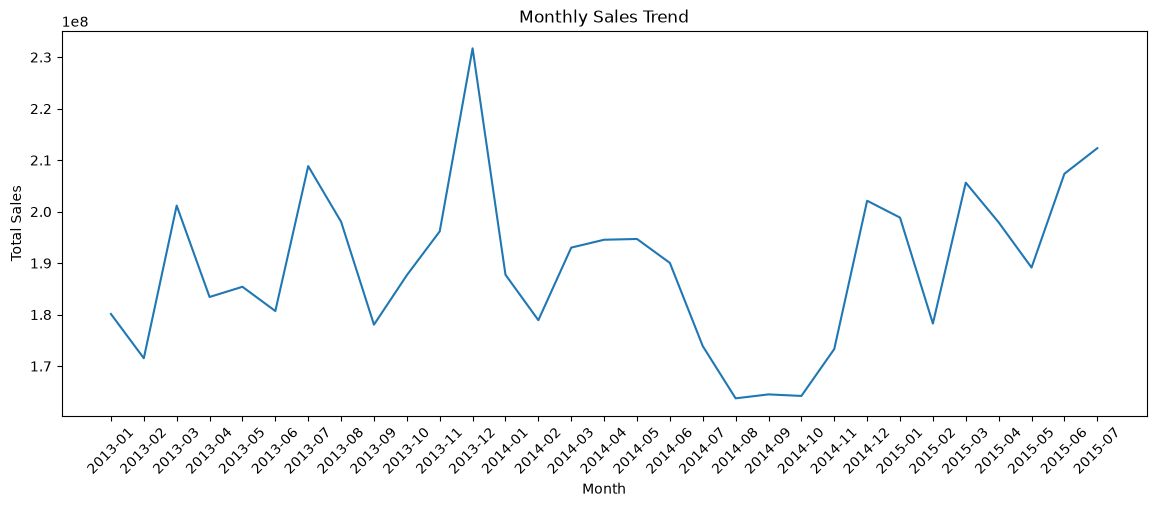

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales["Period"],
    monthly_sales["Sales"]
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")

plt.show()

In [20]:
#Promotional impact, percentage difference
promo_sales = (
    df_open
    .groupby("Promo")["Sales"]
    .agg(["mean", "median", "sum", "count"])
)

display(promo_sales)

,mean,median,sum,count
Promo,,,,
0,5929.407603,5459.0,2771974337,467496
1,8228.281239,7649.0,3101206286,376896


In [21]:
normal_sales = promo_sales.loc[0, "mean"]
promo_sales_avg = promo_sales.loc[1, "mean"]

increase = ((promo_sales_avg - normal_sales) / normal_sales) * 100

print(f"Average sales increase during promotion: {increase:.2f}%")

Average sales increase during promotion: 38.77%


In [22]:
#Do more customers generate more sales?
correlation = df_open[["Sales", "Customers"]].corr()

display(correlation)

,Sales,Customers
Sales,1.000000,0.823597
Customers,0.823597,1.000000


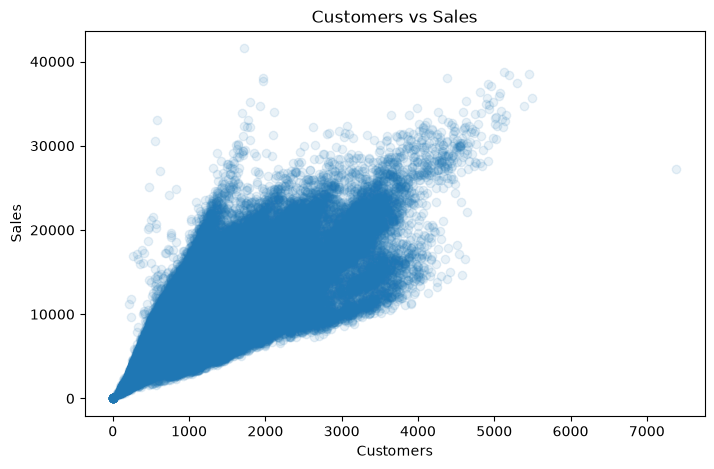

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_open["Customers"],
    df_open["Sales"],
    alpha=0.1
)

plt.xlabel("Customers")
plt.ylabel("Sales")
plt.title("Customers vs Sales")

plt.show()

In [24]:
#Which store has high volatility, higher or lower demand
store_performance = (
    df_open
    .groupby("Store")["Sales"]
    .agg(
        Average_Sales="mean",
        Total_Sales="sum",
        Sales_Std="std"
    )
    .reset_index()
)

display(
    store_performance
    .sort_values("Average_Sales", ascending=False)
    .head(10)
)

,Store,Average_Sales,Total_Sales,Sales_Std
816,817,21757.483418,17057867,4674.803920
261,262,20718.515924,19516842,4668.877584
1113,1114,20666.562500,16202585,3452.938601
250,251,19123.068036,14896870,3547.641612
841,842,18574.795820,11553523,3788.985548
512,513,18179.089286,14252406,3284.600584
561,562,17969.556263,16927322,2931.927599
787,788,17961.914541,14082141,3150.647649
382,383,17294.716667,13489879,2785.813354
755,756,16574.816431,12911782,3912.558675


In [25]:
#Lowest demand stores
display(
    store_performance
    .sort_values("Average_Sales")
    .head(10)
)

,Store,Average_Sales,Total_Sales,Sales_Std
306,307,2703.736573,2114322,1032.828693
542,543,2790.380282,2179287,1237.698497
197,198,2900.604859,2268273,1597.761904
207,208,2936.290816,2302052,716.525610
840,841,2972.608974,2318635,1096.262686
253,254,3005.983312,2341661,832.141965
793,794,3083.812821,2405374,575.952359
218,219,3133.712452,2441162,822.266544
209,210,3193.984596,2488114,849.289001
424,425,3237.659794,2512424,897.185401


In [26]:
#Coefficient of variation (demand volatility)
store_performance["CV"] = (
    store_performance["Sales_Std"]
    / store_performance["Average_Sales"]
)

In [27]:
display(
    store_performance
    .sort_values("CV", ascending=False)
    .head(10)
)

,Store,Average_Sales,Total_Sales,Sales_Std,CV
197,198,2900.604859,2268273,1597.761904,0.550837
896,897,3492.944730,2717511,1810.461801,0.518320
606,607,3901.910486,3051294,1879.566980,0.481704
125,126,6507.753530,5069540,3049.536739,0.468601
574,575,5367.566613,3343994,2472.728592,0.460680
707,708,4571.989826,3145529,2070.314067,0.452826
588,589,4672.622193,3537175,2113.234629,0.452259
542,543,2790.380282,2179287,1237.698497,0.443559
875,876,9228.909922,7069345,4079.722505,0.442059
270,271,7841.691026,6116519,3439.783302,0.438653


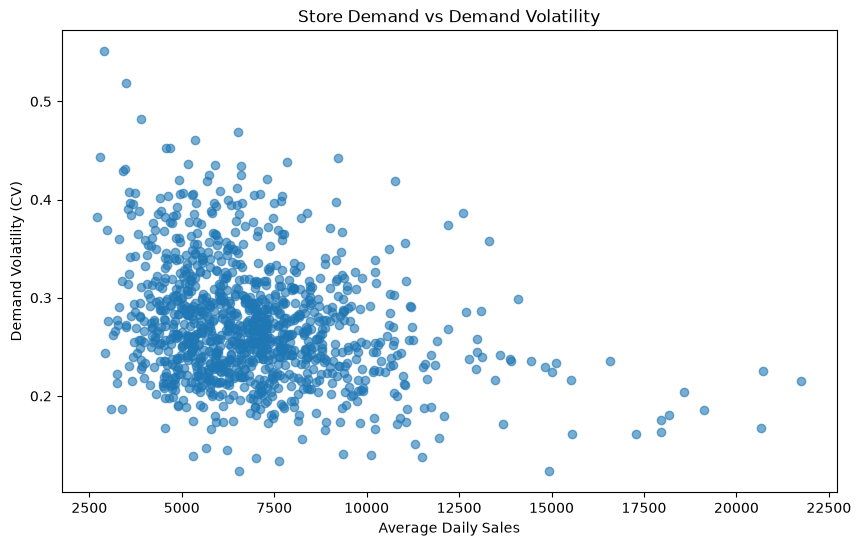

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    store_performance["Average_Sales"],
    store_performance["CV"],
    alpha=0.6
)

plt.xlabel("Average Daily Sales")
plt.ylabel("Demand Volatility (CV)")
plt.title("Store Demand vs Demand Volatility")

plt.show()

In [29]:
#Does store format influence sales

store_type_analysis = (
    df_open
    .groupby("StoreType")["Sales"]
    .agg(
        Average_Sales="mean",
        Median_Sales="median",
        Sales_Std="std"
    )
    .reset_index()
)

display(store_type_analysis)

,StoreType,Average_Sales,Median_Sales,Sales_Std
0,a,6925.167661,6285.0,3277.786381
1,b,10231.407505,9130.0,5157.190155
2,c,6932.512755,6407.0,2897.564578
3,d,6822.141881,6395.0,2556.582881


In [30]:
display(
    df_open
    .groupby("StoreType")["Customers"]
    .mean()
    .reset_index(name="Average_Customers")
)

,StoreType,Average_Customers
0,a,795.361469
1,b,2021.822335
2,c,815.465887
3,d,606.339876


In [31]:
#Create weekly sales, converts each date into the monday of corresponding week
df_open["WeekStart"] = (
    df_open["Date"]
    - pd.to_timedelta(df_open["Date"].dt.dayofweek, unit="D")
)

In [32]:
#Aggregate sales by store and week
weekly_sales = (
    df_open
    .groupby(["Store", "WeekStart"])
    .agg(
        Weekly_Sales=("Sales", "sum"),
        Weekly_Customers=("Customers", "sum"),
        Promo_Days=("Promo", "sum"),
        Open_Days=("Open", "sum")
    )
    .reset_index()
)

In [33]:
print(weekly_sales.shape)
display(weekly_sales.head(10))

(145815, 6)


,Store,WeekStart,Weekly_Sales,Weekly_Customers,Promo_Days,Open_Days
0,1,2012-12-31,19340,2500,0,4
1,1,2013-01-07,32952,3918,5,6
2,1,2013-01-14,25978,3417,0,6
3,1,2013-01-21,33071,3862,5,6
4,1,2013-01-28,28693,3561,0,6
5,1,2013-02-04,35771,4094,5,6
6,1,2013-02-11,27880,3637,0,6
7,1,2013-02-18,32951,3880,5,6
8,1,2013-02-25,27027,3481,0,6
9,1,2013-03-04,37016,4363,5,6


In [34]:
weekly_sales = weekly_sales.sort_values(
    ["Store", "WeekStart"]
)

In [35]:
#Create target
weekly_sales["Next_Week_Sales"] = (
    weekly_sales
    .groupby("Store")["Weekly_Sales"]
    .shift(-1)
)

In [36]:
#Create historical lag features to show to the model
weekly_sales["Sales_Lag_1"] = (
    weekly_sales
    .groupby("Store")["Weekly_Sales"]
    .shift(1)
)

weekly_sales["Sales_Lag_2"] = (
    weekly_sales
    .groupby("Store")["Weekly_Sales"]
    .shift(2)
)

weekly_sales["Sales_Lag_4"] = (
    weekly_sales
    .groupby("Store")["Weekly_Sales"]
    .shift(4)
)

In [37]:
#Create rolling demand (prev 4 weeks sales but dont include recent week)
weekly_sales["Rolling_Mean_4"] = (
    weekly_sales
    .groupby("Store")["Weekly_Sales"]
    .transform(
        lambda x: x.shift(1).rolling(4).mean()
    )
)

In [38]:
weekly_sales["Rolling_Std_4"] = (
    weekly_sales
    .groupby("Store")["Weekly_Sales"]
    .transform(
        lambda x: x.shift(1).rolling(4).std()
    )
)

In [39]:
#add calender features
weekly_sales["Month"] = (
    weekly_sales["WeekStart"].dt.month
)

weekly_sales["Quarter"] = (
    weekly_sales["WeekStart"].dt.quarter
)

In [40]:
weekly_sales["WeekOfYear"] = (
    weekly_sales["WeekStart"].dt.isocalendar().week.astype(int)
)

In [41]:
weekly_sales = weekly_sales.dropna(
    subset=[
        "Next_Week_Sales",
        "Sales_Lag_1",
        "Sales_Lag_2",
        "Sales_Lag_4",
        "Rolling_Mean_4",
        "Rolling_Std_4"
    ]
).copy()

In [42]:
print(weekly_sales.shape)
display(weekly_sales.head())

(140240, 15)


,Store,WeekStart,Weekly_Sales,Weekly_Customers,Promo_Days,Open_Days,Next_Week_Sales,Sales_Lag_1,Sales_Lag_2,Sales_Lag_4,Rolling_Mean_4,Rolling_Std_4,Month,Quarter,WeekOfYear
4,1,2013-01-28,28693,3561,0,6,35771.0,33071.0,25978.0,19340.0,27835.25,6562.846404,1,1,5
5,1,2013-02-04,35771,4094,5,6,27880.0,28693.0,33071.0,32952.0,30173.50,3459.752833,2,1,6
6,1,2013-02-11,27880,3637,0,6,32951.0,35771.0,28693.0,25978.0,30878.25,4379.304463,2,1,7
7,1,2013-02-18,32951,3880,5,6,27027.0,27880.0,35771.0,33071.0,31353.75,3724.136354,2,1,8
8,1,2013-02-25,27027,3481,0,6,37016.0,32951.0,27880.0,28693.0,31323.75,3706.131620,2,1,9


In [43]:
#merge store types (required columns only)
store_features = store[
    [
        "Store",
        "StoreType",
        "Assortment",
        "CompetitionDistance",
        "Promo2"
    ]
].copy()

In [44]:
weekly_sales = weekly_sales.merge(
    store_features,
    on="Store",
    how="left"
)

In [45]:
print(weekly_sales.shape)

display(
    weekly_sales[
        [
            "Store",
            "StoreType",
            "Assortment",
            "CompetitionDistance",
            "Promo2",
            "Weekly_Sales",
            "Next_Week_Sales"
        ]
    ].head()
)

(140240, 19)


,Store,StoreType,Assortment,CompetitionDistance,Promo2,Weekly_Sales,Next_Week_Sales
0,1,c,a,1270.0,0,28693,35771.0
1,1,c,a,1270.0,0,35771,27880.0
2,1,c,a,1270.0,0,27880,32951.0
3,1,c,a,1270.0,0,32951,27027.0
4,1,c,a,1270.0,0,27027,37016.0


In [46]:
median_distance = weekly_sales["CompetitionDistance"].median()

weekly_sales["CompetitionDistance"] = (
    weekly_sales["CompetitionDistance"]
    .fillna(median_distance)
)

In [47]:
print(
    weekly_sales["CompetitionDistance"].isna().sum()
)

0


In [48]:
print("Start:", weekly_sales["WeekStart"].min())
print("End:", weekly_sales["WeekStart"].max())

Start: 2013-01-28 00:00:00
End: 2015-07-20 00:00:00


In [49]:
validation_start = (
    weekly_sales["WeekStart"].max()
    - pd.DateOffset(months=3)
)

print("Validation starts:", validation_start)

Validation starts: 2015-04-20 00:00:00


In [50]:
#Create train test validation set
train_data = weekly_sales[
    weekly_sales["WeekStart"] < validation_start
].copy()

validation_data = weekly_sales[
    weekly_sales["WeekStart"] >= validation_start
].copy()

In [51]:
print("Training:", train_data.shape)
print("Validation:", validation_data.shape)

print(
    "\nTraining period:",
    train_data["WeekStart"].min(),
    "→",
    train_data["WeekStart"].max()
)

print(
    "Validation period:",
    validation_data["WeekStart"].min(),
    "→",
    validation_data["WeekStart"].max()
)

Training: (124638, 19)
Validation: (15602, 19)

Training period: 2013-01-28 00:00:00 → 2015-04-13 00:00:00
Validation period: 2015-04-20 00:00:00 → 2015-07-20 00:00:00


In [52]:
#define features( the ones the model sees)
features = [
    "Sales_Lag_1",
    "Sales_Lag_2",
    "Sales_Lag_4",
    "Rolling_Mean_4",
    "Rolling_Std_4",
    "Month",
    "Quarter",
    "WeekOfYear",
    "StoreType",
    "Assortment",
    "CompetitionDistance",
    "Promo2"
]

target = "Next_Week_Sales"

In [53]:
X_train = train_data[features]
y_train = train_data[target]

X_val = validation_data[features]
y_val = validation_data[target]

In [54]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (124638, 12)
y_train: (124638,)
X_val: (15602, 12)
y_val: (15602,)


In [55]:
#Starting with naive forecast(base calculation that does the prev week's sales will be same as this week's sales)
y_pred_baseline = validation_data["Weekly_Sales"]

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [57]:
baseline_mae = mean_absolute_error(
    y_val,
    y_pred_baseline
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_baseline
    )
)

print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))

Baseline MAE: 11199.99
Baseline RMSE: 12658.91


In [58]:
baseline_wape = (
    np.abs(y_val - y_pred_baseline).sum()
    / np.abs(y_val).sum()
) * 100

print("Baseline WAPE:", round(baseline_wape, 2), "%")

Baseline WAPE: 26.9 %


In [59]:
from sklearn.metrics import r2_score

baseline_r2 = r2_score(
    y_val,
    y_pred_baseline
)

print("Baseline R²:", round(baseline_r2, 4))

Baseline R²: 0.3937


In [60]:
baseline_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "WAPE (%)",
        "R²"
    ],
    "Baseline": [
        baseline_mae,
        baseline_rmse,
        baseline_wape,
        baseline_r2
    ]
})

display(baseline_results)

,Metric,Baseline
0,MAE,11199.986732
1,RMSE,12658.906160
2,WAPE (%),26.900634
3,R²,0.393692


In [61]:
#1st model : Random forest (first use one hot encoder for the store type encoding)
X_train_encoded = pd.get_dummies(
    X_train,
    columns=["StoreType", "Assortment"],
    drop_first=True
)

X_val_encoded = pd.get_dummies(
    X_val,
    columns=["StoreType", "Assortment"],
    drop_first=True
)

In [62]:
X_val_encoded = X_val_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [63]:
print("Training features:", X_train_encoded.shape)
print("Validation features:", X_val_encoded.shape)

Training features: (124638, 15)
Validation features: (15602, 15)


In [64]:
from sklearn.ensemble import RandomForestRegressor

In [65]:
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

In [66]:
rf_model.fit(
    X_train_encoded,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [67]:
rf_predictions = rf_model.predict(
    X_val_encoded
)

print(rf_predictions[:10])

[27854.90127135 26813.05027508 24996.95886407 28517.54908086
 21683.72985893 28558.88600627 21978.26678097 26730.31735166
 22702.47278691 27938.1593243 ]


In [68]:
rf_mae = mean_absolute_error(
    y_val,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        rf_predictions
    )
)

rf_wape = (
    np.abs(y_val - rf_predictions).sum()
    / np.abs(y_val).sum()
) * 100

rf_r2 = r2_score(
    y_val,
    rf_predictions
)

print("Random Forest MAE:", round(rf_mae, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))
print("Random Forest WAPE:", round(rf_wape, 2), "%")
print("Random Forest R²:", round(rf_r2, 4))

Random Forest MAE: 3493.34
Random Forest RMSE: 5010.86
Random Forest WAPE: 8.39 %
Random Forest R²: 0.905


In [69]:
model_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "WAPE (%)",
        "R²"
    ],
    "Baseline": [
        baseline_mae,
        baseline_rmse,
        baseline_wape,
        baseline_r2
    ],
    "Random Forest": [
        rf_mae,
        rf_rmse,
        rf_wape,
        rf_r2
    ]
})

display(model_comparison)

,Metric,Baseline,Random Forest
0,MAE,11199.986732,3493.338902
1,RMSE,12658.906160,5010.859010
2,WAPE (%),26.900634,8.390459
3,R²,0.393692,0.905000


In [70]:
#Which features helped random forest make better predictions
feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.head(10))

,Feature,Importance
0,Sales_Lag_1,0.555855
3,Rolling_Mean_4,0.297782
7,WeekOfYear,0.090919
1,Sales_Lag_2,0.023445
2,Sales_Lag_4,0.013032
5,Month,0.007461
4,Rolling_Std_4,0.006480
8,CompetitionDistance,0.002551
6,Quarter,0.000986
14,Assortment_c,0.000396


In [71]:
pip install catboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 4.4 MB/s eta 0:00:24
    --------------------------------------- 2.1/101.7 MB 4.8 MB/s eta 0:00:21
   - -------------------------------------- 2.6/101.7 MB 3.7 MB/s eta 0:00:27
   - -------------------------------------- 3.7/101.7 MB 3.9 MB/s eta 0:00:26
   - -------------------------------------- 4.5/101.7 MB 3.9 MB/s eta 0:00:25
   -- ------------------------------------- 5.2/101.7 MB 3.8 MB/s eta 0:00:26
   -- ------------------------------------- 6.0/101.7 MB 3.8 MB/s eta 0:00:26
   -- ------------------------------------- 6.6/101.7 MB 3.7 MB/s eta 0:00:26
   -- ------------------------------------- 7.3/101.7 MB 3.7 MB/s eta 0:00:26
   --- ------------------------------------ 8.1/101.7 MB 3.6 MB/s eta 0:00:26
   --- ------------------------------------ 8.9/101.7 MB 3.6 MB/s eta 0:00:26


In [72]:
#Trying catboost as 2nd model
import catboost

print(catboost.__version__)

1.2.10


In [73]:
X_train_cb = X_train.copy()
X_val_cb = X_val.copy()

In [74]:
categorical_features = [
    "StoreType",
    "Assortment"
]

In [75]:
from catboost import CatBoostRegressor

cb_model = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

In [76]:
cb_model.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_features
)

0:	learn: 16027.2361838	total: 327ms	remaining: 2m 43s
100:	learn: 5588.4876638	total: 19.2s	remaining: 1m 15s
200:	learn: 4932.8679420	total: 38.6s	remaining: 57.4s
300:	learn: 4652.5306189	total: 57.8s	remaining: 38.2s
400:	learn: 4493.7838193	total: 1m 17s	remaining: 19.1s
499:	learn: 4383.0248870	total: 1m 37s	remaining: 0us


CatBoostRegressor(depth=8, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [77]:
cb_predictions = cb_model.predict(
    X_val_cb
)

print(cb_predictions[:10])

[27767.30212449 28602.49883219 23121.06088144 25430.34626804
 22756.69988495 32048.29461247 20547.65010717 25212.07359616
 23765.0328864  28851.19837035]


In [78]:
cb_mae = mean_absolute_error(
    y_val,
    cb_predictions
)

cb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        cb_predictions
    )
)

cb_wape = (
    np.abs(y_val - cb_predictions).sum()
    / np.abs(y_val).sum()
) * 100

cb_r2 = r2_score(
    y_val,
    cb_predictions
)

print("CatBoost MAE:", round(cb_mae, 2))
print("CatBoost RMSE:", round(cb_rmse, 2))
print("CatBoost WAPE:", round(cb_wape, 2), "%")
print("CatBoost R²:", round(cb_r2, 4))

CatBoost MAE: 3612.88
CatBoost RMSE: 4863.43
CatBoost WAPE: 8.68 %
CatBoost R²: 0.9105


In [79]:
final_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "WAPE (%)",
        "R²"
    ],
    "Baseline": [
        baseline_mae,
        baseline_rmse,
        baseline_wape,
        baseline_r2
    ],
    "Random Forest": [
        rf_mae,
        rf_rmse,
        rf_wape,
        rf_r2
    ],
    "CatBoost": [
        cb_mae,
        cb_rmse,
        cb_wape,
        cb_r2
    ]
})

display(final_comparison)

,Metric,Baseline,Random Forest,CatBoost
0,MAE,11199.986732,3493.338902,3612.875858
1,RMSE,12658.906160,5010.859010,4863.427177
2,WAPE (%),26.900634,8.390459,8.677568
3,R²,0.393692,0.905000,0.910508


In [80]:
#Visualize the results
forecast_results = validation_data[
    [
        "Store",
        "WeekStart",
        "Weekly_Sales",
        "Next_Week_Sales"
    ]
].copy()

forecast_results["Predicted_Sales"] = rf_predictions

In [81]:
display(forecast_results.head(10))

,Store,WeekStart,Weekly_Sales,Next_Week_Sales,Predicted_Sales
116,1,2015-04-20,20670,28627.0,27854.901271
117,1,2015-04-27,28627,29272.0,26813.050275
118,1,2015-05-04,29272,19705.0,24996.958864
119,1,2015-05-11,19705,27740.0,28517.549081
120,1,2015-05-18,27740,22653.0,21683.729859
121,1,2015-05-25,22653,26600.0,28558.886006
122,1,2015-06-01,26600,23342.0,21978.266781
123,1,2015-06-08,23342,27314.0,26730.317352
124,1,2015-06-15,27314,21823.0,22702.472787
125,1,2015-06-22,21823,31175.0,27938.159324


In [82]:
#too many stores will create a messy graph, choosing one store for graphing
store_id = 262

store_forecast = (
    forecast_results[
        forecast_results["Store"] == store_id
    ]
    .sort_values("WeekStart")
)

display(store_forecast.head())

,Store,WeekStart,Weekly_Sales,Next_Week_Sales,Predicted_Sales
32849,262,2015-04-20,130781,177915.0,142990.120771
32850,262,2015-04-27,177915,147764.0,140466.884642
32851,262,2015-05-04,147764,161139.0,154786.633181
32852,262,2015-05-11,161139,148020.0,148155.777134
32853,262,2015-05-18,148020,164724.0,147091.497649


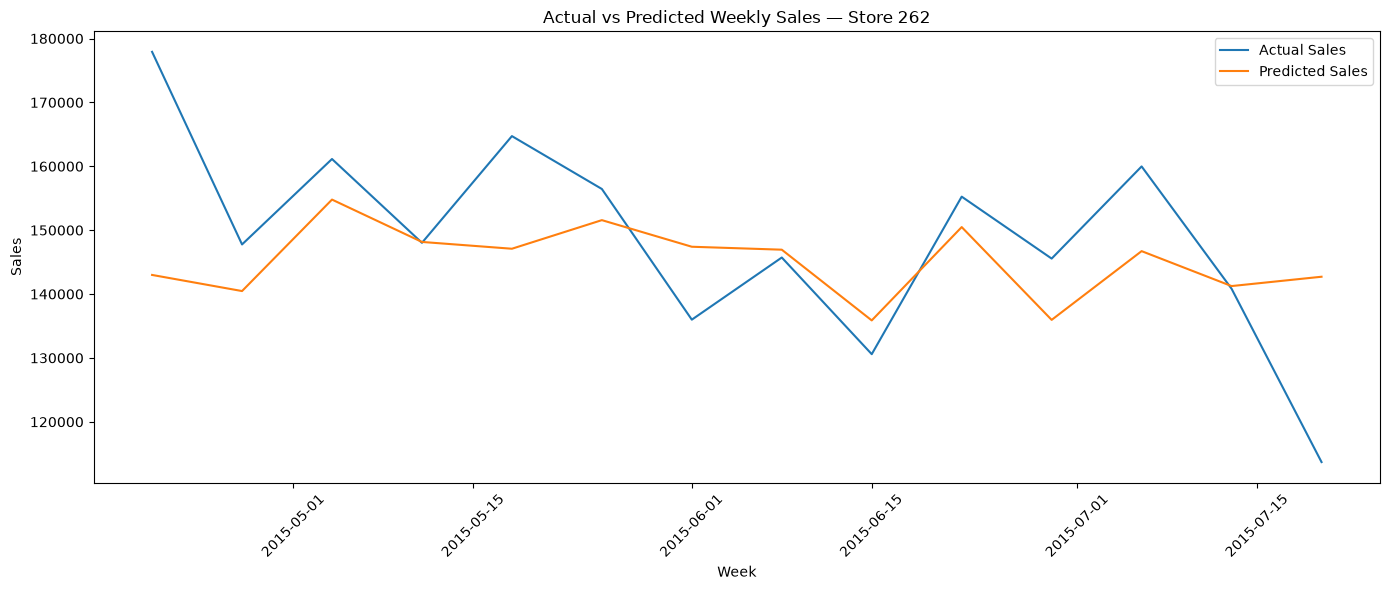

In [83]:
#Plotting for actual vs predicted
plt.figure(figsize=(14, 6))

plt.plot(
    store_forecast["WeekStart"],
    store_forecast["Next_Week_Sales"],
    label="Actual Sales"
)

plt.plot(
    store_forecast["WeekStart"],
    store_forecast["Predicted_Sales"],
    label="Predicted Sales"
)

plt.xlabel("Week")
plt.ylabel("Sales")
plt.title(f"Actual vs Predicted Weekly Sales — Store {store_id}")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [84]:
#Forecast erros
forecast_results["Error"] = (
    forecast_results["Next_Week_Sales"]
    - forecast_results["Predicted_Sales"]
)

forecast_results["Absolute_Error"] = (
    forecast_results["Error"].abs()
)

In [85]:
display(
    forecast_results[
        [
            "Store",
            "WeekStart",
            "Next_Week_Sales",
            "Predicted_Sales",
            "Error",
            "Absolute_Error"
        ]
    ].head(10)
)

,Store,WeekStart,Next_Week_Sales,Predicted_Sales,Error,Absolute_Error
116,1,2015-04-20,28627.0,27854.901271,772.098729,772.098729
117,1,2015-04-27,29272.0,26813.050275,2458.949725,2458.949725
118,1,2015-05-04,19705.0,24996.958864,-5291.958864,5291.958864
119,1,2015-05-11,27740.0,28517.549081,-777.549081,777.549081
120,1,2015-05-18,22653.0,21683.729859,969.270141,969.270141
121,1,2015-05-25,26600.0,28558.886006,-1958.886006,1958.886006
122,1,2015-06-01,23342.0,21978.266781,1363.733219,1363.733219
123,1,2015-06-08,27314.0,26730.317352,583.682648,583.682648
124,1,2015-06-15,21823.0,22702.472787,-879.472787,879.472787
125,1,2015-06-22,31175.0,27938.159324,3236.840676,3236.840676


In [86]:
#where our model struggled the most
largest_errors = (
    forecast_results
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
)

display(largest_errors)

,Store,WeekStart,Weekly_Sales,Next_Week_Sales,Predicted_Sales,Error,Absolute_Error
114209,909,2015-06-29,20353,16051.0,95299.976938,-79248.976938,79248.976938
114207,909,2015-06-15,88334,118573.0,52987.470879,65585.529121,65585.529121
110149,876,2015-06-29,78921,100142.0,45662.432478,54479.567522,54479.567522
114208,909,2015-06-22,118573,20353.0,66230.008368,-45877.008368,45877.008368
36555,292,2015-06-22,30393,83012.0,39922.549778,43089.450222,43089.450222
122103,971,2015-04-27,29642,10009.0,50918.684164,-40909.684164,40909.684164
70689,562,2015-07-20,112599,94188.0,131100.146795,-36912.146795,36912.146795
32849,262,2015-04-20,130781,177915.0,142990.120771,34924.879229,34924.879229
96602,769,2015-07-20,76797,59387.0,94198.418682,-34811.418682,34811.418682
122104,971,2015-05-11,10009,84805.0,51986.806489,32818.193511,32818.193511


In [87]:
#Calculate error per store
store_error = (
    forecast_results
    .groupby("Store")
    .agg(
        Actual_Sales=("Next_Week_Sales", "sum"),
        Predicted_Sales=("Predicted_Sales", "sum"),
        MAE=("Absolute_Error", "mean")
    )
    .reset_index()
)

In [88]:
display(
    store_error
    .sort_values("MAE", ascending=False)
    .head(10)
)

,Store,Actual_Sales,Predicted_Sales,MAE
908,909,858686.0,8.496114e+05,24092.631529
875,876,692041.0,6.476080e+05,13294.332904
970,971,630568.0,6.756740e+05,11833.452814
841,842,1641248.0,1.590035e+06,11483.449149
261,262,2083599.0,2.032389e+06,10442.490800
260,261,967462.0,9.813194e+05,10268.450688
34,35,936578.0,9.185503e+05,9934.445648
379,380,1180961.0,1.162032e+06,9918.271416
210,211,1136702.0,1.083413e+06,9835.191381
787,788,1485596.0,1.469072e+06,9822.428768
